In [92]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [94]:
import pandas as pd
df= pd.read_csv("/content/drive/MyDrive/MLT /preprocessing_dataset.csv")
df1=df.copy()
df2=df.copy()

In [95]:
df.head()

,Name,Age,Gender,Salary,Department
0,Alice,25.0,F,50000.0,HR
1,Bob,30.0,M,60000.0,Finance
2,Charlie,NaN,M,55000.0,IT
3,David,40.0,M,58000.0,HR
4,Eve,22.0,F,52000.0,IT


In [96]:
df.tail()

,Name,Age,Gender,Salary,Department
5,Frank,35.0,NaN,61000.0,Finance
6,Grace,120.0,F,NaN,Finance
7,Henry,28.0,M,59000.0,HR
8,Ivy,29.0,F,63000.0,IT
9,Jack,27.0,M,62000.0,Finance


In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        10 non-null     object 
 1   Age         9 non-null      float64
 2   Gender      9 non-null      object 
 3   Salary      9 non-null      float64
 4   Department  10 non-null     object 
dtypes: float64(2), object(3)
memory usage: 532.0+ bytes


In [98]:
df.describe()

,Age,Salary
count,9.000000,9.000000
mean,39.555556,57777.777778
std,30.631320,4521.553322
min,22.000000,50000.000000
25%,27.000000,55000.000000
50%,29.000000,59000.000000
75%,35.000000,61000.000000
max,120.000000,63000.000000


<Axes: >

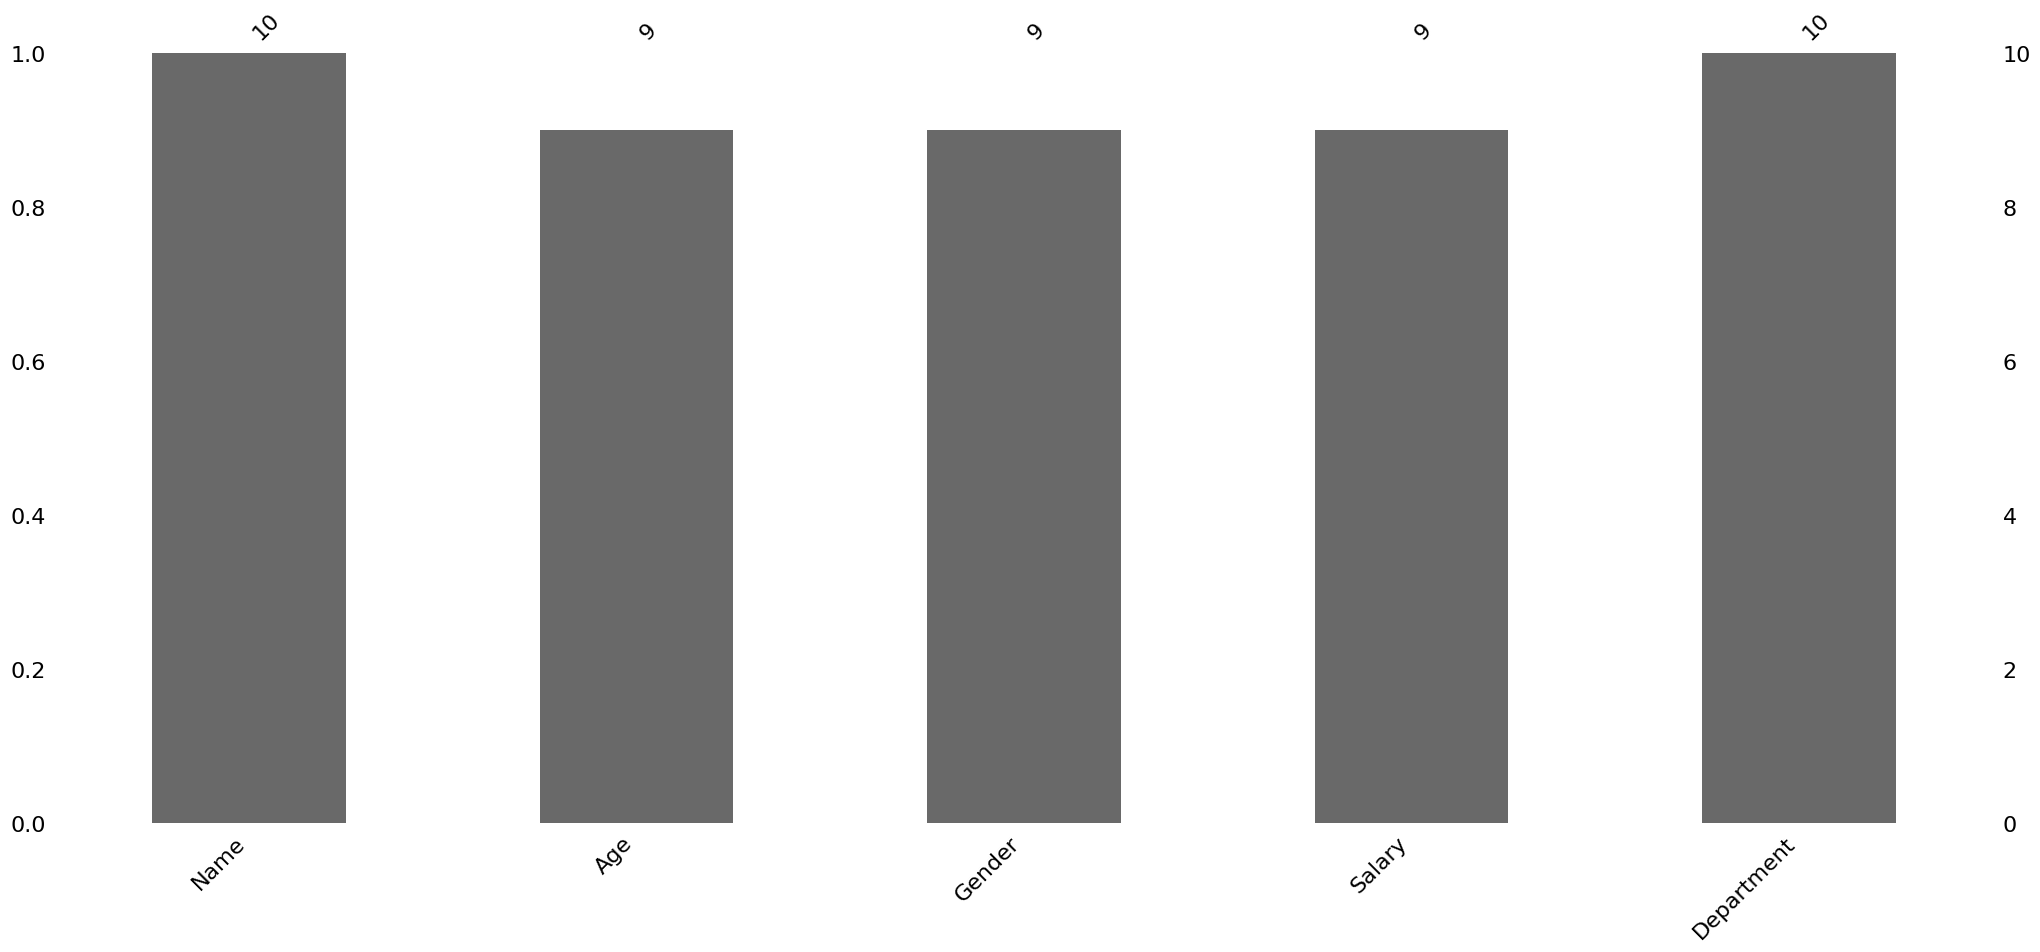

In [99]:
import missingno as msno
msno.bar(df)

In [100]:
msno.matrix

<function missingno.missingno.matrix(df, filter=None, n=0, p=0, sort=None, figsize=(25, 10), width_ratios=(15, 1), color=(0.25, 0.25, 0.25), fontsize=16, labels=None, label_rotation=45, sparkline=True, freq=None, ax=None)>

<Axes: >

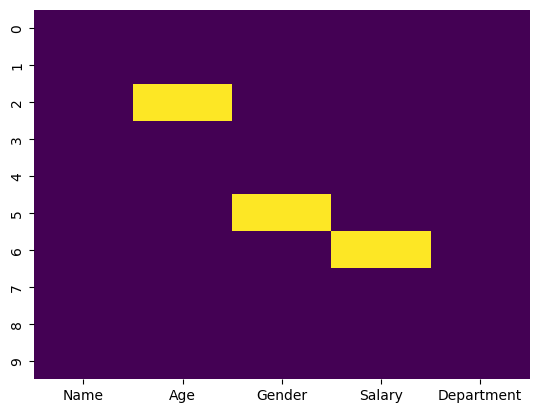

In [101]:
import seaborn as sns
sns.heatmap(df.isnull(),cbar=False,cmap='viridis')

In [102]:

df['Age'].fillna(df['Age'].mean(),inplace=True)
df['Salary'].fillna(df['Salary'].mean(),inplace=True)
df['Gender'].fillna(df['Gender'].mode()[0],inplace=True)


/tmp/ipykernel_7624/2987008262.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)
/tmp/ipykernel_7624/2987008262.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [103]:
print(df)

      Name         Age Gender        Salary Department
0    Alice   25.000000      F  50000.000000         HR
1      Bob   30.000000      M  60000.000000    Finance
2  Charlie   39.555556      M  55000.000000         IT
3    David   40.000000      M  58000.000000         HR
4      Eve   22.000000      F  52000.000000         IT
5    Frank   35.000000      M  61000.000000    Finance
6    Grace  120.000000      F  57777.777778    Finance
7    Henry   28.000000      M  59000.000000         HR
8      Ivy   29.000000      F  63000.000000         IT
9     Jack   27.000000      M  62000.000000    Finance


In [104]:
from sklearn.impute import SimpleImputer
imp = SimpleImputer(strategy='median')
df1[['Age']]=imp.fit_transform(df1[['Age']])
df1

,Name,Age,Gender,Salary,Department
0,Alice,25.0,F,50000.0,HR
1,Bob,30.0,M,60000.0,Finance
2,Charlie,29.0,M,55000.0,IT
3,David,40.0,M,58000.0,HR
4,Eve,22.0,F,52000.0,IT
5,Frank,35.0,NaN,61000.0,Finance
6,Grace,120.0,F,NaN,Finance
7,Henry,28.0,M,59000.0,HR
8,Ivy,29.0,F,63000.0,IT
9,Jack,27.0,M,62000.0,Finance


In [105]:
from sklearn.impute import SimpleImputer
imp = SimpleImputer(strategy='most_frequent')
df1[['Gender']]=imp.fit_transform(df1[['Gender']])
df1

,Name,Age,Gender,Salary,Department
0,Alice,25.0,F,50000.0,HR
1,Bob,30.0,M,60000.0,Finance
2,Charlie,29.0,M,55000.0,IT
3,David,40.0,M,58000.0,HR
4,Eve,22.0,F,52000.0,IT
5,Frank,35.0,M,61000.0,Finance
6,Grace,120.0,F,NaN,Finance
7,Henry,28.0,M,59000.0,HR
8,Ivy,29.0,F,63000.0,IT
9,Jack,27.0,M,62000.0,Finance


<Axes: ylabel='Age'>

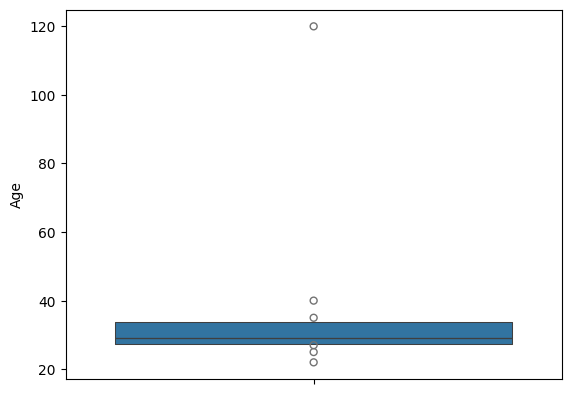

In [106]:
sns.boxenplot(df1['Age'])

In [107]:
Q1=df['Age'].quantile(0.25)
Q3=df['Age'].quantile(0.75)
iqr=Q3-Q1
lower_bound=Q1-1.5*iqr
upper_bound=Q3+1.5*iqr
outlier=df[(df['Age']<lower_bound)| (df['Age']>upper_bound)]
outlier


,Name,Age,Gender,Salary,Department
6,Grace,120.0,F,57777.777778,Finance


In [108]:
from scipy.stats import zscore
z_score=zscore(df['Age'])
df[np.abs(z_score)>2.5]

,Name,Age,Gender,Salary,Department
6,Grace,120.0,F,57777.777778,Finance


In [109]:
from sklearn.ensemble import IsolationForest
iso=IsolationForest(contamination=0.1)
df['outlier']=iso.fit_predict(df[['Age','Salary']])
df[df['outlier']==-1]

,Name,Age,Gender,Salary,Department,outlier
6,Grace,120.0,F,57777.777778,Finance,-1


In [110]:
from scipy.stats.mstats import winsorize
df['Age_Winsorized'] = winsorize(df['Age'], limits=[0.05, 0.05])
print(df[['Age', 'Age_Winsorized']])

          Age  Age_Winsorized
0   25.000000       25.000000
1   30.000000       30.000000
2   39.555556       39.555556
3   40.000000       40.000000
4   22.000000       22.000000
5   35.000000       35.000000
6  120.000000      120.000000
7   28.000000       28.000000
8   29.000000       29.000000
9   27.000000       27.000000


In [111]:
import numpy as np
df['Age_Log'] = np.log1p(df['Age'])
print(df[['Age', 'Age_Log']])

          Age   Age_Log
0   25.000000  3.258097
1   30.000000  3.433987
2   39.555556  3.702673
3   40.000000  3.713572
4   22.000000  3.135494
5   35.000000  3.583519
6  120.000000  4.795791
7   28.000000  3.367296
8   29.000000  3.401197
9   27.000000  3.332205


In [112]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')
df['Age_Power'] = pt.fit_transform(df[['Age']])
print(df[['Age', 'Age_Power']])

          Age  Age_Power
0   25.000000  -0.966514
1   30.000000  -0.100378
2   39.555556   0.784877
3   40.000000   0.812389
4   22.000000  -1.758521
5   35.000000   0.445352
6  120.000000   1.987909
7   28.000000  -0.396398
8   29.000000  -0.241400
9   27.000000  -0.567315


In [113]:
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
df['Gender_encoder']=le.fit_transform(df['Gender'])
df

,Name,Age,Gender,Salary,Department,outlier,Age_Winsorized,Age_Log,Age_Power,Gender_encoder
0,Alice,25.000000,F,50000.000000,HR,1,25.000000,3.258097,-0.966514,0
1,Bob,30.000000,M,60000.000000,Finance,1,30.000000,3.433987,-0.100378,1
2,Charlie,39.555556,M,55000.000000,IT,1,39.555556,3.702673,0.784877,1
3,David,40.000000,M,58000.000000,HR,1,40.000000,3.713572,0.812389,1
4,Eve,22.000000,F,52000.000000,IT,1,22.000000,3.135494,-1.758521,0
5,Frank,35.000000,M,61000.000000,Finance,1,35.000000,3.583519,0.445352,1
6,Grace,120.000000,F,57777.777778,Finance,-1,120.000000,4.795791,1.987909,0
7,Henry,28.000000,M,59000.000000,HR,1,28.000000,3.367296,-0.396398,1
8,Ivy,29.000000,F,63000.000000,IT,1,29.000000,3.401197,-0.241400,0
9,Jack,27.000000,M,62000.000000,Finance,1,27.000000,3.332205,-0.567315,1


In [114]:
from sklearn.preprocessing import OneHotEncoder
one=OneHotEncoder(sparse_output=False)
df['Gender']=one.fit_transform(df[['Gender']])
df

,Name,Age,Gender,Salary,Department,outlier,Age_Winsorized,Age_Log,Age_Power,Gender_encoder
0,Alice,25.000000,1.0,50000.000000,HR,1,25.000000,3.258097,-0.966514,0
1,Bob,30.000000,0.0,60000.000000,Finance,1,30.000000,3.433987,-0.100378,1
2,Charlie,39.555556,0.0,55000.000000,IT,1,39.555556,3.702673,0.784877,1
3,David,40.000000,0.0,58000.000000,HR,1,40.000000,3.713572,0.812389,1
4,Eve,22.000000,1.0,52000.000000,IT,1,22.000000,3.135494,-1.758521,0
5,Frank,35.000000,0.0,61000.000000,Finance,1,35.000000,3.583519,0.445352,1
6,Grace,120.000000,1.0,57777.777778,Finance,-1,120.000000,4.795791,1.987909,0
7,Henry,28.000000,0.0,59000.000000,HR,1,28.000000,3.367296,-0.396398,1
8,Ivy,29.000000,1.0,63000.000000,IT,1,29.000000,3.401197,-0.241400,0
9,Jack,27.000000,0.0,62000.000000,Finance,1,27.000000,3.332205,-0.567315,1


In [115]:
df1=pd.get_dummies(df1,columns=['Gender'],drop_first=True)
df1

,Name,Age,Salary,Department,Gender_M
0,Alice,25.0,50000.0,HR,False
1,Bob,30.0,60000.0,Finance,True
2,Charlie,29.0,55000.0,IT,True
3,David,40.0,58000.0,HR,True
4,Eve,22.0,52000.0,IT,False
5,Frank,35.0,61000.0,Finance,True
6,Grace,120.0,NaN,Finance,False
7,Henry,28.0,59000.0,HR,True
8,Ivy,29.0,63000.0,IT,False
9,Jack,27.0,62000.0,Finance,True
